In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("restaurant-analysis.csv",encoding="latin-1")

print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [14]:
print(df.shape)

(9551, 21)


In [34]:
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## Average rating by cuisine type — bar chart

In [17]:
# Reyting-i 0-da yüksək olanları seçək
df_clean = df[df["Aggregate rating"] > 0 ].copy() # Not rated

# Neçə sətir silindi?
print(f"Əvvəl: {len(df)} ,İndi: {len(df_clean)},Silinmiş: {len(df)-len(df_clean)}")

Əvvəl: 9551 ,İndi: 7403,Silinmiş: 2148


In [18]:
# Hər restoranıntərkibində fərqli Cuisines var , onları split edek  [French,  Japanese,  Desserts]
df_clean['Cuisines'] = df_clean['Cuisines'].str.split(',')

In [19]:
# Eyni sətirdə olan listi sətir-sətir ayıraq
df_exploded = df_clean.explode('Cuisines')

# Boşluqları təmizləyək  (', Chinese' -> 'Chinese')
df_exploded['Cuisines'] = df_exploded['Cuisines'].str.strip()

In [20]:
# (16276, 21) (7403, 21) - Cuisines böldüyümüz üçün sətir sayı artır

print(df_exploded.shape)
print(df_clean.shape)
# print(df_exploded)

(16276, 21)
(7403, 21)


In [21]:
#  30-dan cox restoranı olan mətbəxləri seçək

cuisine_details = df_exploded.groupby('Cuisines')['Aggregate rating'].agg(['mean','count']).reset_index()
cuisine_details.columns = ["Cuisine",'Avg_Rating','Restaurant_Count']
cuisine_details.sort_values('Restaurant_Count',ascending=False)
cuisine_filtered = cuisine_details[cuisine_details['Restaurant_Count']>30]

In [22]:
cuisine_top15 = cuisine_filtered.sort_values('Avg_Rating',ascending=False).head(15)
print(cuisine_top15)

           Cuisine  Avg_Rating  Restaurant_Count
64          Indian    4.156061                66
14        Bar Food    4.145946                37
114       Sandwich    4.066038                53
12             BBQ    4.025000                32
86   Mediterranean    4.020000               110
126          Steak    3.985484                62
129          Sushi    3.973333                75
21       Breakfast    3.965854                41
47        European    3.964384               146
116        Seafood    3.929825               171
7            Asian    3.898684               228
87         Mexican    3.872989               174
71        Japanese    3.825373               134
2         American    3.757895               380
69         Italian    3.748485               726


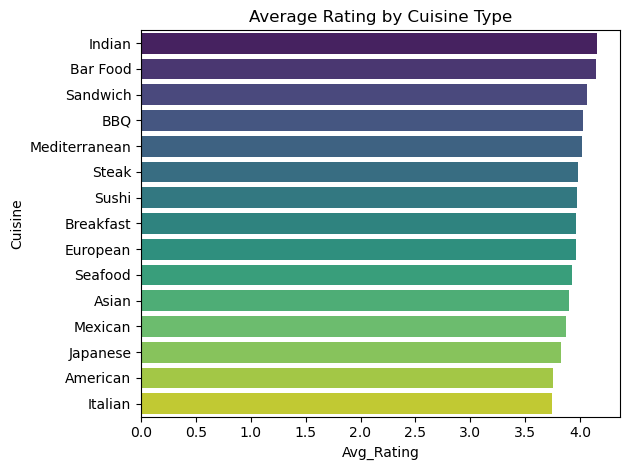

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x='Avg_Rating', y='Cuisine', data=cuisine_top15, palette = 'viridis',hue='Cuisine', legend=False)
plt.title('Average Rating by Cuisine Type')
plt.xlabel('Avg_Rating')
plt.ylabel('Cuisine')
plt.savefig('cuisine_bar_chart.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Price range vs rating comparison

In [24]:
# Price range details
print(df_clean['Price range'].unique())

[3 4 2 1]


In [25]:
# 
price_details = df_clean.groupby(['Price range'])['Aggregate rating'].agg(['mean','count']).reset_index()
price_details.columns = ["Price_Range", "Avg_Rating", "Restaurant_Count"]
print(price_details.sort_values('Price_Range',ascending=True))

   Price_Range  Avg_Rating  Restaurant_Count
0            1    3.238885              2744
1            2    3.377167              2711
2            3    3.777276              1373
3            4    3.890957               575


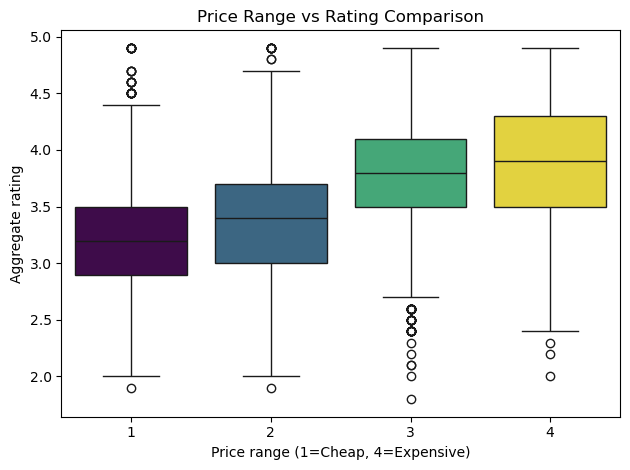

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_clean, x='Price range', y='Aggregate rating',
            hue='Price range', palette='viridis', legend=False)
plt.title('Price Range vs Rating Comparison')
plt.xlabel('Price range (1=Cheap, 4=Expensive)')
plt.ylabel('Aggregate rating')
plt.savefig('price_boxplot.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Review Count vs Rating (Scatter Plot)

In [27]:
print(df_clean['Votes'].describe())

count     7403.000000
mean       202.185060
std        479.195199
min          4.000000
25%         19.000000
50%         60.000000
75%        181.000000
max      10934.000000
Name: Votes, dtype: float64


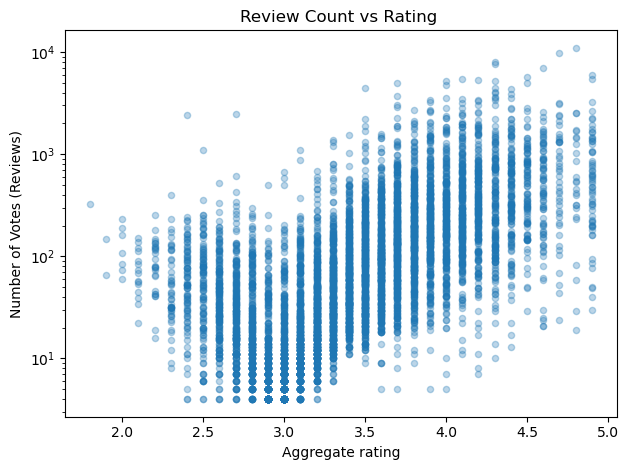

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.scatter(data=df_clean,x='Aggregate rating',y='Votes',alpha=0.3,s=20)
plt.yscale('log')
plt.title("Review Count vs Rating ")
plt.xlabel("Aggregate rating")
plt.ylabel("Number of Votes (Reviews)")
plt.savefig('review_scatter.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [29]:
# Korrelyasiya əmsalı nə deyir? (məs. 0.3 zəif müsbət əlaqə deməkdir)
# Çox rəy alan restoranların reytinqi ümumiyyətlə yüksəkdirmi?
# Yoxsa az rəy alan restoranlar arasında da yüksək rating olanlar var (yəni "gizli incilər")?

In [30]:
print(df_clean['Aggregate rating'].corr(df_clean['Votes']))

0.40901786341810825


### City-level performance breakdown

In [31]:
city_details = df_clean.groupby(['City'])['Aggregate rating'].agg(['mean','count']).reset_index()
city_details.columns=['City','Avg_Rating','Restaurant_Count']

city_filtered = city_details[city_details['Restaurant_Count'] >= 20]
city_filtered = city_filtered.sort_values('Avg_Rating', ascending=False)
city_filtered2 = city_filtered.sort_values('Restaurant_Count', ascending=False)

top15_cities = city_filtered.head(15)
bottom15_cities = city_filtered2.head(15)
print(top15_cities)
print(bottom15_cities)

                City  Avg_Rating  Restaurant_Count
67            London       4.535                20
91           Orlando       4.475                20
110   Rest of Hawaii       4.410                20
124        Tampa Bay       4.410                20
14         Bangalore       4.375                20
39             Dubai       4.370                20
26           Chennai       4.315                20
6             Ankara       4.305                20
0          Abu Dhabi       4.300                20
9           Auckland       4.275                20
20             Boise       4.260                20
63           Kolkata       4.255                20
137  Wellington City       4.250                20
49               Goa       4.245                20
36        Des Moines       4.235                20
               City  Avg_Rating  Restaurant_Count
88        New Delhi    3.297381              4048
50          Gurgaon    3.330674               890
89            Noida    3.159626   

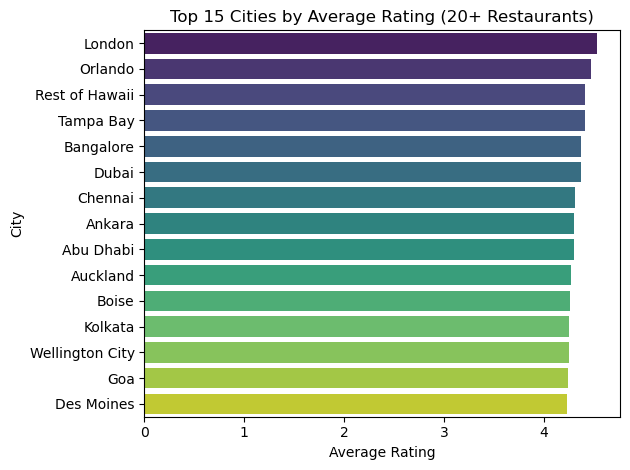

In [41]:
sns.barplot(data=top15_cities, x='Avg_Rating', y='City', hue='City', palette='viridis', legend=False)
plt.title('Top 15 Cities by Average Rating (20+ Restaurants)')
plt.xlabel('Average Rating')
plt.ylabel('City')
plt.savefig('city_top15.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

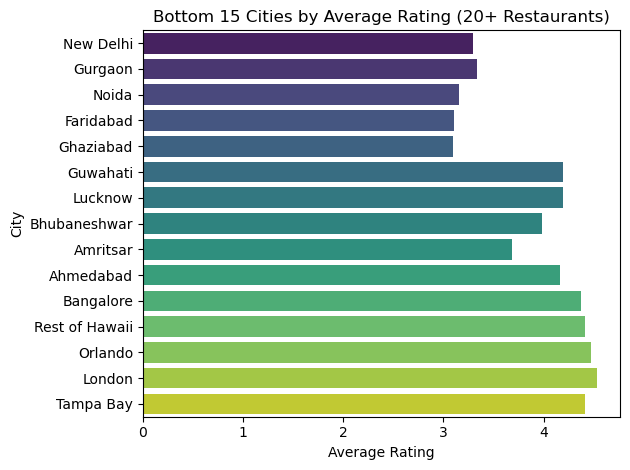

In [42]:
sns.barplot(data=bottom15_cities, x='Avg_Rating', y='City', hue='City', palette='viridis', legend=False)
plt.title('Bottom 15 Cities by Average Rating (20+ Restaurants)')
plt.xlabel('Average Rating')
plt.ylabel('City')
plt.savefig('city_bottom15.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

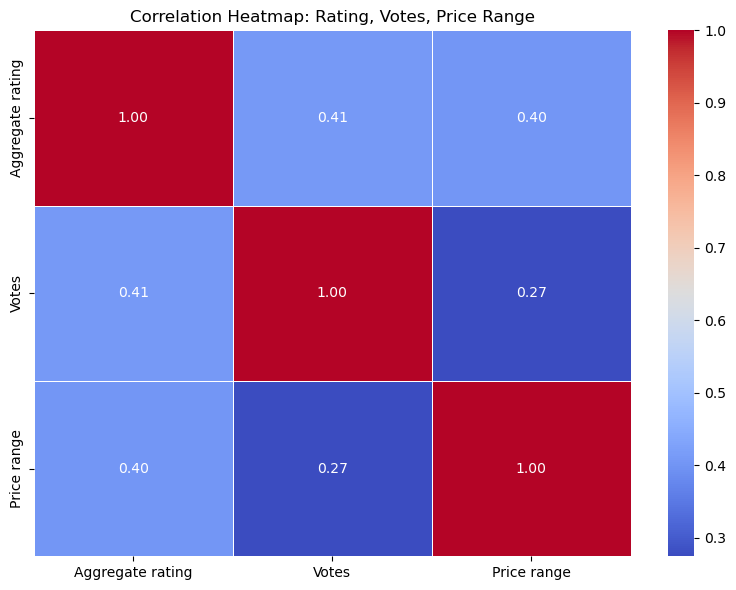

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_clean[['Aggregate rating', 'Votes', 'Price range']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Rating, Votes, Price Range')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()